# Assignment 4

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("https://raw.githubusercontent.com/TheChroniclerr/CP321/refs/heads/main/a4/assets/COVID_Country_Sample.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      300 non-null    object 
 1   country                   300 non-null    object 
 2   new_cases                 300 non-null    int64  
 3   new_deaths                300 non-null    int64  
 4   new_vaccinations          294 non-null    float64
 5   population                300 non-null    int64  
 6   cases_per_million         300 non-null    float64
 7   vaccinations_per_hundred  300 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 18.9+ KB


,date,country,new_cases,new_deaths,new_vaccinations,population,cases_per_million,vaccinations_per_hundred
0,2020-01-01,Canada,383,1,0.0,38000000,10.09,0.0
1,2020-02-01,Canada,582,2,0.0,38000000,15.32,0.0
2,2020-03-01,Canada,738,10,0.0,38000000,19.43,0.0
3,2020-04-01,Canada,692,8,0.0,38000000,18.24,0.0
4,2020-05-01,Canada,392,3,0.0,38000000,10.32,0.0


## Clean

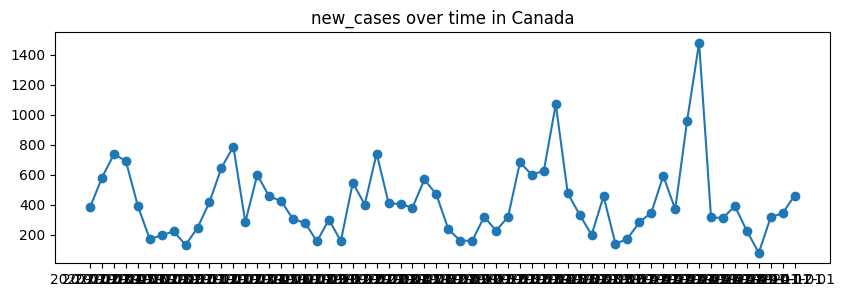

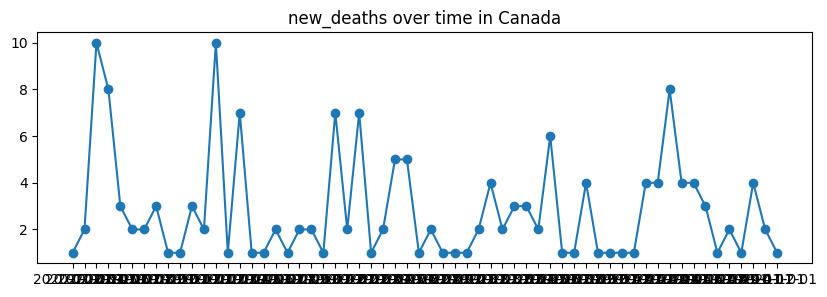

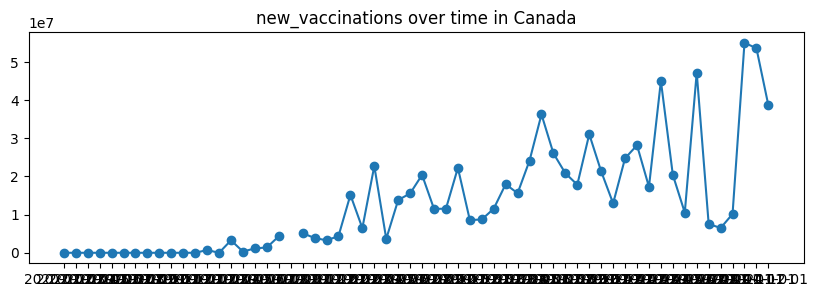

,0
date,0
country,0
new_cases,0
new_deaths,0
new_vaccinations,6
population,0
cases_per_million,0
vaccinations_per_hundred,0


In [28]:
# Check outliers
country = 'Canada'
df_can = df[df['country'] == country]
numeric_cols = ['new_cases', 'new_deaths', 'new_vaccinations']

for col in numeric_cols:
    plt.figure(figsize=(10,3))
    plt.plot(df_can['date'], df_can[col], marker='o')
    plt.title(f'{col} over time in {country}')
    plt.show()

# Check missing values
df.isna().sum()

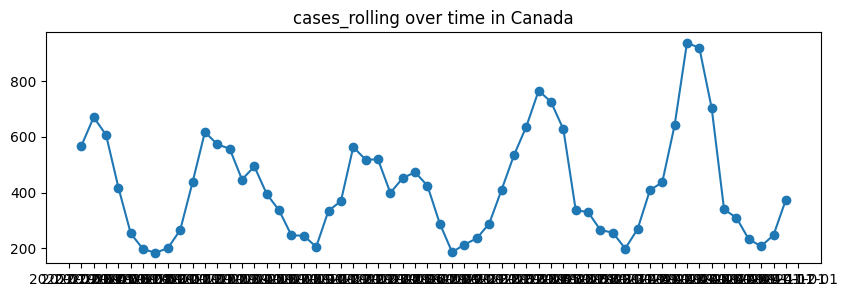

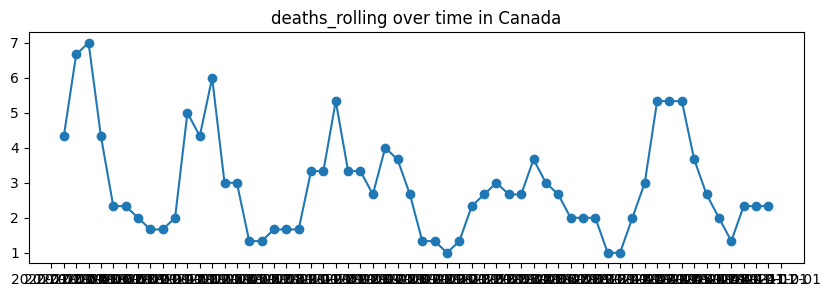

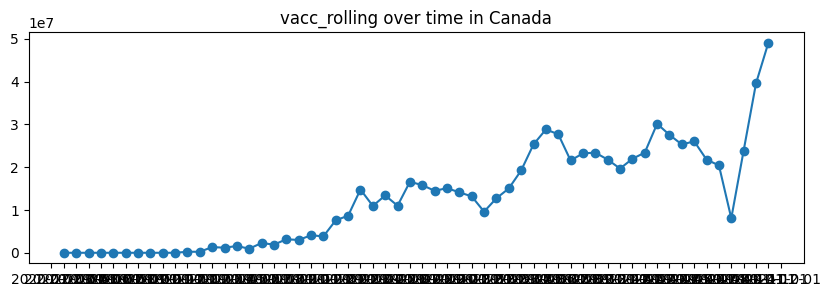

,0
date,0
country,0
new_cases,0
new_deaths,0
new_vaccinations,0
population,0
cases_per_million,0
vaccinations_per_hundred,0
cases_rolling,10
deaths_rolling,10


In [29]:
# Zero-fill Nan values
df['new_vaccinations'] = df['new_vaccinations'].fillna(0)

# Compute rolling mean
df['cases_rolling'] = df.groupby('country')['new_cases'].transform(lambda x: x.rolling(3, center=True).mean())
df['deaths_rolling'] = df.groupby('country')['new_deaths'].transform(lambda x: x.rolling(3, center=True).mean())
df['vacc_rolling'] = df.groupby('country')['new_vaccinations'].transform(lambda x: x.rolling(3, center=True).mean())

# Check again
country = 'Canada'
df_can = df[df['country'] == country]
numeric_cols = ['cases_rolling', 'deaths_rolling', 'vacc_rolling']

for col in numeric_cols:
    plt.figure(figsize=(10,3))
    plt.plot(df_can['date'], df_can[col], marker='o')
    plt.title(f'{col} over time in {country}')
    plt.show()

df.isna().sum()